--- Frequency Table for Sleep Hours ---
Sleep_Hours
4.0      743
5.0     1235
6.0     2713
7.0     3594
8.0     2772
9.0      739
10.0     246
Name: count, dtype: int64


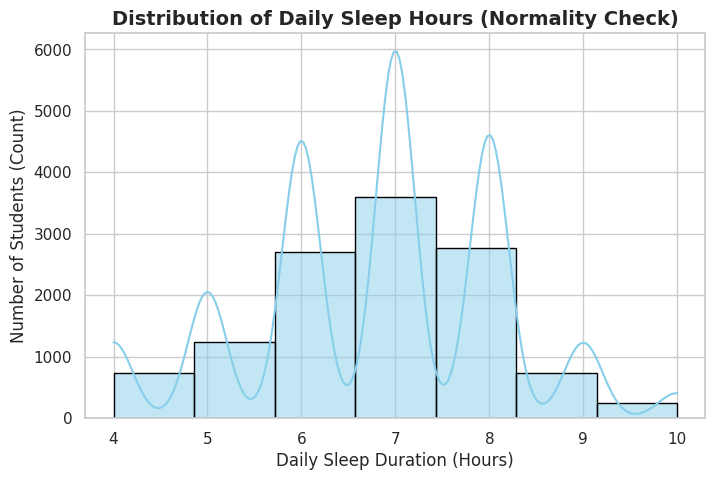

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. Load Data and Clean (Ensuring df_final is defined in this cell)
# =========================================================================
df = pd.read_csv('YRBS_2007.csv')

# Map sleep codes to actual hours
sleep_map = {1: 4, 2: 5, 3: 6, 4: 7, 5: 8, 6: 9, 7: 10}
df['Sleep_Hours'] = df['Sleep'].map(sleep_map)

# Recode aerobic exercise into groups
def recode_aerobic(value):
    if value in [1, 2]:        return 'Low'
    elif value in [3, 4, 5]:    return 'Medium'
    elif value in [6, 7, 8]:    return 'High'
    else:                       return np.nan

df['Exercise_Group'] = df['AerobicExercise'].apply(recode_aerobic)

# Create the final cleaned dataframe
df_final = df[['Exercise_Group', 'Sleep_Hours']].dropna()

# =========================================================================
# 2. Calculate and Display the Frequency Table (次數分配表)
# =========================================================================
print("--- Frequency Table for Sleep Hours ---")
# This counts how many students chose each sleep hour
frequency_table = df_final['Sleep_Hours'].value_counts().sort_index()
print(frequency_table)

# =========================================================================
# 3. Plot the Distribution to Check Normality (常態性檢定直方圖)
# =========================================================================
# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Draw the histogram with a Kernel Density Estimate (KDE) line
sns.histplot(df_final['Sleep_Hours'], kde=True, bins=7, color='skyblue', edgecolor='black')

# Add English titles and labels for the final presentation
plt.title('Distribution of Daily Sleep Hours (Normality Check)', fontsize=14, fontweight='bold')
plt.xlabel('Daily Sleep Duration (Hours)', fontsize=12)
plt.ylabel('Number of Students (Count)', fontsize=12)

# Save the figure as an image for GitHub / Infographic
plt.savefig('sleep_normality_histogram.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

/tmp/ipykernel_3625/322924198.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exercise_Group', y='Sleep_Hours', data=df_final, order=group_order, palette="Set2")


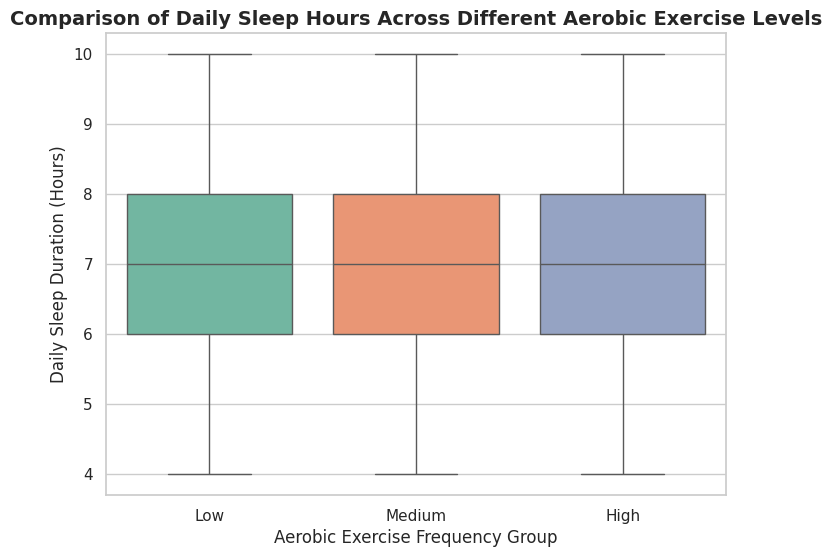

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================================
# 1. Load Data and Clean (Ensuring df_final is defined in this cell)
# =========================================================================
df = pd.read_csv('YRBS_2007.csv')

# Map sleep codes to actual hours
sleep_map = {1: 4, 2: 5, 3: 6, 4: 7, 5: 8, 6: 9, 7: 10}
df['Sleep_Hours'] = df['Sleep'].map(sleep_map)

# Recode aerobic exercise into groups
def recode_aerobic(value):
    if value in [1, 2]:        return 'Low'
    elif value in [3, 4, 5]:    return 'Medium'
    elif value in [6, 7, 8]:    return 'High'
    else:                       return np.nan

df['Exercise_Group'] = df['AerobicExercise'].apply(recode_aerobic)

# Create the final cleaned dataframe
df_final = df[['Exercise_Group', 'Sleep_Hours']].dropna()

# =========================================================================
# 2. Plot the Boxplot (畫箱型圖)
# =========================================================================
# Set the visual style of the plot
sns.set_theme(style="whitegrid")

# Create a figure with a professional size
plt.figure(figsize=(8, 6))

# Set the correct order for the X-axis so it flows from Low to High frequency
group_order = ['Low', 'Medium', 'High']

# Draw the Boxplot
sns.boxplot(x='Exercise_Group', y='Sleep_Hours', data=df_final, order=group_order, palette="Set2")

# Add professional titles and labels in English for your final project
plt.title('Comparison of Daily Sleep Hours Across Different Aerobic Exercise Levels', fontsize=14, fontweight='bold')
plt.xlabel('Aerobic Exercise Frequency Group', fontsize=12)
plt.ylabel('Daily Sleep Duration (Hours)', fontsize=12)

# Save the figure as an image file for GitHub and your Infographic
plt.savefig('exercise_sleep_boxplot.png', dpi=300, bbox_inches='tight')

# Display the plot
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# 1. Re-load and clean data to ensure no NameError
df = pd.read_csv('YRBS_2007.csv')

sleep_map = {1: 4, 2: 5, 3: 6, 4: 7, 5: 8, 6: 9, 7: 10}
df['Sleep_Hours'] = df['Sleep'].map(sleep_map)

def recode_aerobic(value):
    if value in [1, 2]:        return 'Low'
    elif value in [3, 4, 5]:    return 'Medium'
    elif value in [6, 7, 8]:    return 'High'
    else:                       return np.nan

df['Exercise_Group'] = df['AerobicExercise'].apply(recode_aerobic)
df_final = df[['Exercise_Group', 'Sleep_Hours']].dropna()

# =========================================================================
# 2. Separate groups and calculate Group Means
# =========================================================================
print("--- Average Sleep Hours for Each Group ---")
group_means = df_final.groupby('Exercise_Group')['Sleep_Hours'].mean()
print(group_means)
print("-" * 40)

# =========================================================================
# 3. Perform One-way ANOVA Test
# =========================================================================
low_group = df_final[df_final['Exercise_Group'] == 'Low']['Sleep_Hours']
medium_group = df_final[df_final['Exercise_Group'] == 'Medium']['Sleep_Hours']
high_group = df_final[df_final['Exercise_Group'] == 'High']['Sleep_Hours']

f_stat, p_val = stats.f_oneway(low_group, medium_group, high_group)

print("\n=== One-way ANOVA Test Results ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\nDecision: Reject H0. There IS a statistically significant difference!")
else:
    print("\nDecision: Fail to Reject H0. There is NO statistically significant difference.")

--- Average Sleep Hours for Each Group ---
Exercise_Group
High      6.926567
Low       6.671665
Medium    6.736897
Name: Sleep_Hours, dtype: float64
----------------------------------------

=== One-way ANOVA Test Results ===
F-statistic: 41.2666
p-value: 1.3781e-18

Decision: Reject H0. There IS a statistically significant difference!


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_final['Sleep_Hours'],
                          groups=df_final['Exercise_Group'],
                          alpha=0.05)

print("=== Tukey's HSD Post-hoc Test Results ===")
print(tukey)


=== Tukey's HSD Post-hoc Test Results ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  High    Low  -0.2549    0.0  -0.326 -0.1838   True
  High Medium  -0.1897    0.0 -0.2572 -0.1222   True
   Low Medium   0.0652 0.1052 -0.0101  0.1406  False
----------------------------------------------------


/tmp/ipykernel_3625/3978109710.py:8: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='Exercise_Group', y='Sleep_Hours', data=df_final,


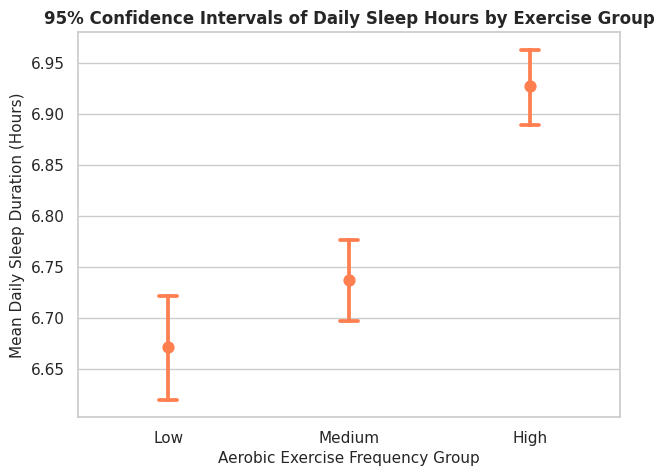

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))

group_order = ['Low', 'Medium', 'High']
sns.pointplot(x='Exercise_Group', y='Sleep_Hours', data=df_final,
              order=group_order, join=False, color='coral', capsize=0.1)

plt.title('95% Confidence Intervals of Daily Sleep Hours by Exercise Group', fontsize=12, fontweight='bold')
plt.xlabel('Aerobic Exercise Frequency Group', fontsize=11)
plt.ylabel('Mean Daily Sleep Duration (Hours)', fontsize=11)

plt.savefig('exercise_sleep_mean_plot.png', dpi=300, bbox_inches='tight')
plt.show()